In [1]:
import os, json
import pandas as pd

clamp = ["front", "back", "mid"]
tasks = ["STS22", "ArguAna"]
max_piece_lengths = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

data = []

for c in clamp:
    for t in tasks:
        for m in max_piece_lengths:
            json_path = f"/home/S113062628/project/echo-embeddings/mteb_results/echo_mistral/{c}_clamp/{t}/{m}/no_model_name_available/no_revision_available/{t}.json"
            if not os.path.exists(json_path):
                continue
            with open(json_path, "r") as f:
                log_data = json.load(f)
                data.append(
                    {
                        "clamp": c,
                        "task": t,
                        "max_piece_length": m,
                        "main_score": log_data["scores"]["test"][0]["main_score"],
                    }
                )
df = pd.DataFrame(data)
df

,clamp,task,max_piece_length,main_score
0,front,STS22,16,0.132599
1,front,STS22,32,0.312378
2,front,STS22,64,0.558219
3,front,STS22,128,0.576327
4,front,STS22,256,0.584206
5,front,STS22,512,0.556198
6,front,STS22,1024,0.500220
7,front,STS22,2048,0.481001
8,front,STS22,4096,0.488344
9,front,ArguAna,16,0.010150


In [2]:
df_STS22 = df[df["task"] == "STS22"].reset_index(drop=True)
df_ArguAna = df[df["task"] == "ArguAna"].reset_index(drop=True)

In [3]:
df_ArguAna

,clamp,task,max_piece_length,main_score
0,front,ArguAna,16,0.01015
1,front,ArguAna,32,0.04500
2,front,ArguAna,64,0.26312
3,front,ArguAna,128,0.37111
4,front,ArguAna,256,0.33096
5,front,ArguAna,512,0.30441
6,front,ArguAna,1024,0.30199
7,front,ArguAna,2048,0.30269
8,front,ArguAna,4096,0.30269
9,back,ArguAna,16,0.05790


In [4]:
df_STS22.drop(columns=["task"], inplace=True)
df_STS22_front = df_STS22[df_STS22["clamp"] == "front"].reset_index(drop=True)
df_STS22_back = df_STS22[df_STS22["clamp"] == "back"].reset_index(drop=True)
df_STS22_mid = df_STS22[df_STS22["clamp"] == "mid"].reset_index(drop=True)
df_STS22_merged = pd.merge(
    pd.merge(
        df_STS22_front,
        df_STS22_back,
        on="max_piece_length",
        suffixes=("_front", "_back"),
    ),
    df_STS22_mid,
    on="max_piece_length",
)

df_STS22_merged.rename(columns={"main_score": "main_score_mid"}, inplace=True)

df_STS22 = df_STS22_merged

df_STS22.drop(columns=["clamp_front", "clamp_back", "clamp"], inplace=True)

df_STS22["max_token_length"] = df_STS22["max_piece_length"] * 2
df_STS22

,max_piece_length,main_score_front,main_score_back,main_score_mid,max_token_length
0,16,0.132599,0.102984,0.268266,32
1,32,0.312378,0.171338,0.408438,64
2,64,0.558219,0.297670,0.505878,128
3,128,0.576327,0.425912,0.546913,256
4,256,0.584206,0.503095,0.551268,512
5,512,0.556198,0.507437,0.514382,1024
6,1024,0.500220,0.476279,0.486899,2048
7,2048,0.481001,0.473294,0.473338,4096
8,4096,0.488344,0.487918,0.487618,8192


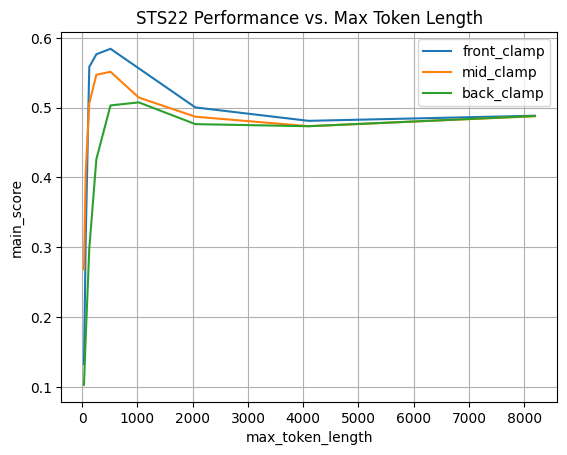

In [5]:
import matplotlib.pyplot as plt

plt.plot(
    df_STS22["max_token_length"], df_STS22["main_score_front"], label="front_clamp"
)
plt.plot(df_STS22["max_token_length"], df_STS22["main_score_mid"], label="mid_clamp")
plt.plot(df_STS22["max_token_length"], df_STS22["main_score_back"], label="back_clamp")
plt.xlabel("max_token_length")
plt.ylabel("main_score")
plt.title("STS22 Performance vs. Max Token Length")
plt.legend()
plt.grid()
plt.show()

In [6]:
df_ArguAna.drop(columns=["task"], inplace=True)
df_ArguAna_front = df_ArguAna[df_ArguAna["clamp"] == "front"].reset_index(drop=True)
df_ArguAna_back = df_ArguAna[df_ArguAna["clamp"] == "back"].reset_index(drop=True)
df_ArguAna_mid = df_ArguAna[df_ArguAna["clamp"] == "mid"].reset_index(drop=True)
df_ArguAna_merged = pd.merge(
    pd.merge(
        df_ArguAna_front,
        df_ArguAna_back,
        on="max_piece_length",
        suffixes=("_front", "_back"),
    ),
    df_ArguAna_mid,
    on="max_piece_length",
)

df_ArguAna_merged.rename(columns={"main_score": "main_score_mid"}, inplace=True)

df_ArguAna = df_ArguAna_merged

df_ArguAna.drop(columns=["clamp_front", "clamp_back", "clamp"], inplace=True)

df_ArguAna["max_token_length"] = df_ArguAna["max_piece_length"] * 2
df_ArguAna

,max_piece_length,main_score_front,main_score_back,main_score_mid,max_token_length
0,16,0.01015,0.05790,0.04361,32
1,32,0.04500,0.08239,0.11124,64
2,64,0.26312,0.14522,0.24562,128
3,128,0.37111,0.24629,0.33860,256
4,256,0.33096,0.29852,0.32319,512
5,512,0.30441,0.30388,0.30599,1024
6,1024,0.30199,0.30182,0.30218,2048
7,2048,0.30269,0.30269,0.30269,4096


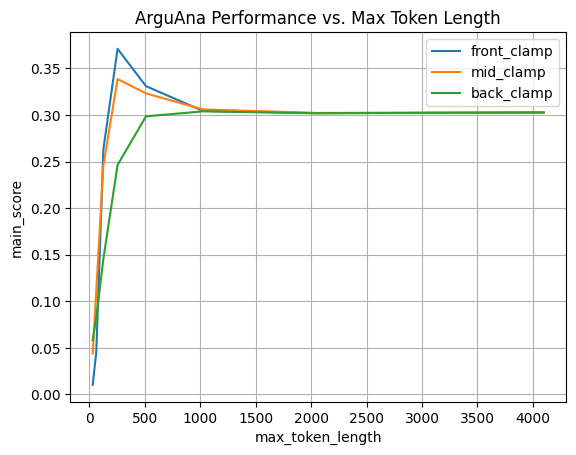

In [7]:
import matplotlib.pyplot as plt

plt.plot(
    df_ArguAna["max_token_length"], df_ArguAna["main_score_front"], label="front_clamp"
)
plt.plot(
    df_ArguAna["max_token_length"], df_ArguAna["main_score_mid"], label="mid_clamp"
)
plt.plot(
    df_ArguAna["max_token_length"], df_ArguAna["main_score_back"], label="back_clamp"
)
plt.xlabel("max_token_length")
plt.ylabel("main_score")
plt.title("ArguAna Performance vs. Max Token Length")
plt.legend()
plt.grid()
plt.show()